In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

def zero_mean(x: np.ndarray):
    return np.zeros(x.shape[0])

def rbf(x1: np.ndarray, x2: np.ndarray, sigma2: float = 1.0, l: np.ndarray | float = 1.0) -> np.ndarray:
    d = (x1[:, None] - x2[None, :]) / l
    d2 = (d**2).sum(axis=-1)
    return sigma2 * np.exp(-0.5 * d2)


class GaussianProcess:
    def __init__(self, m, k, sigma2_noise: float = 0.0):
        self.m_init = m
        self.k_init = k
        self.m = m
        self.k = k
        self.sigma2_noise = sigma2_noise

        self.x = None
        self.y = None

    def sample(self, x: np.ndarray) -> np.ndarray:
        return np.random.multivariate_normal(self.m(x), self.k(x, x))

    def observe(self, x_obs: np.ndarray, y_obs: np.ndarray):
        self.x = x_obs if self.x is None else np.concat((self.x, x_obs), axis=0)
        self.y = y_obs if self.y is None else np.concat((self.y, y_obs), axis=0)

        # Update m.
        A = self.k_init(self.x, self.x) + (self.sigma2_noise + 1e-9)*np.identity(self.x.shape[0])
        L = np.linalg.cholesky(A, upper=False)

        a = scipy.linalg.solve_triangular(L, self.y - self.m_init(self.x), lower=True)
        b = scipy.linalg.solve_triangular(L.T, a, lower=False)

        def new_m(x_new: np.ndarray) -> np.ndarray:
            return self.m_init(x_new) + self.k_init(x_new, self.x) @ b
        self.m = new_m

        # Update k.
        def new_k(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
            a = scipy.linalg.solve_triangular(L, self.k_init(self.x, x2), lower=True)
            b = scipy.linalg.solve_triangular(L.T, a, lower=False)
            return self.k_init(x1, x2) - self.k_init(x1, self.x) @ b
        self.k = new_k

    def log_likelihood(self) -> float:
        A = self.k(self.x, self.x) + (self.sigma2_noise + 1e-9)*np.identity(self.x.shape[0])
        L = np.linalg.cholesky(A, upper=False)
        z = scipy.linalg.solve_triangular(L, self.y - self.m(self.x), lower=True)
        ll = -0.5 * z.T @ z

        log_det = 2 * np.sum(np.log(np.diag(L)))
        ll -= 0.5 * log_det

        ll -= 0.5 * self.x.shape[0] * np.log(2*np.pi)
        return ll


def plot_gp(gp: GaussianProcess, x_new: np.ndarray, ax):
    assert (x_new.ndim == 2) and (x_new.shape[1] == 1)
    mu_new = gp.m(x_new)
    ax.plot(x_new[:, 0], mu_new, "k", label=r"$\mu$")

    sigma2_new = np.diag(gp.k(x_new, x_new))
    sigma_new = np.sqrt(np.maximum(sigma2_new, 0.0))
    ax.fill_between(x_new[:, 0], mu_new - 2*sigma_new, mu_new + 2*sigma_new,
                    color="blue", alpha=0.3, label=r"$\mu \pm 2\sigma$")

    if not (gp.x is None):
        ax.scatter(gp.x[:, 0], gp.y)

def plot_gp_k(gp: GaussianProcess, x_new: np.ndarray, ax):
    img = ax.imshow(gp.k(x_new, x_new))
    return img

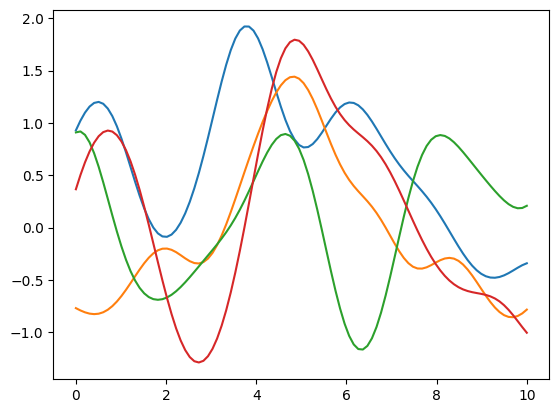

In [2]:
gp = GaussianProcess(m=zero_mean, k=rbf)

x_new = np.linspace(0, 10, 100)[:, None]
for i in range(4):
    plt.plot(x_new, gp.sample(x_new))
plt.show()

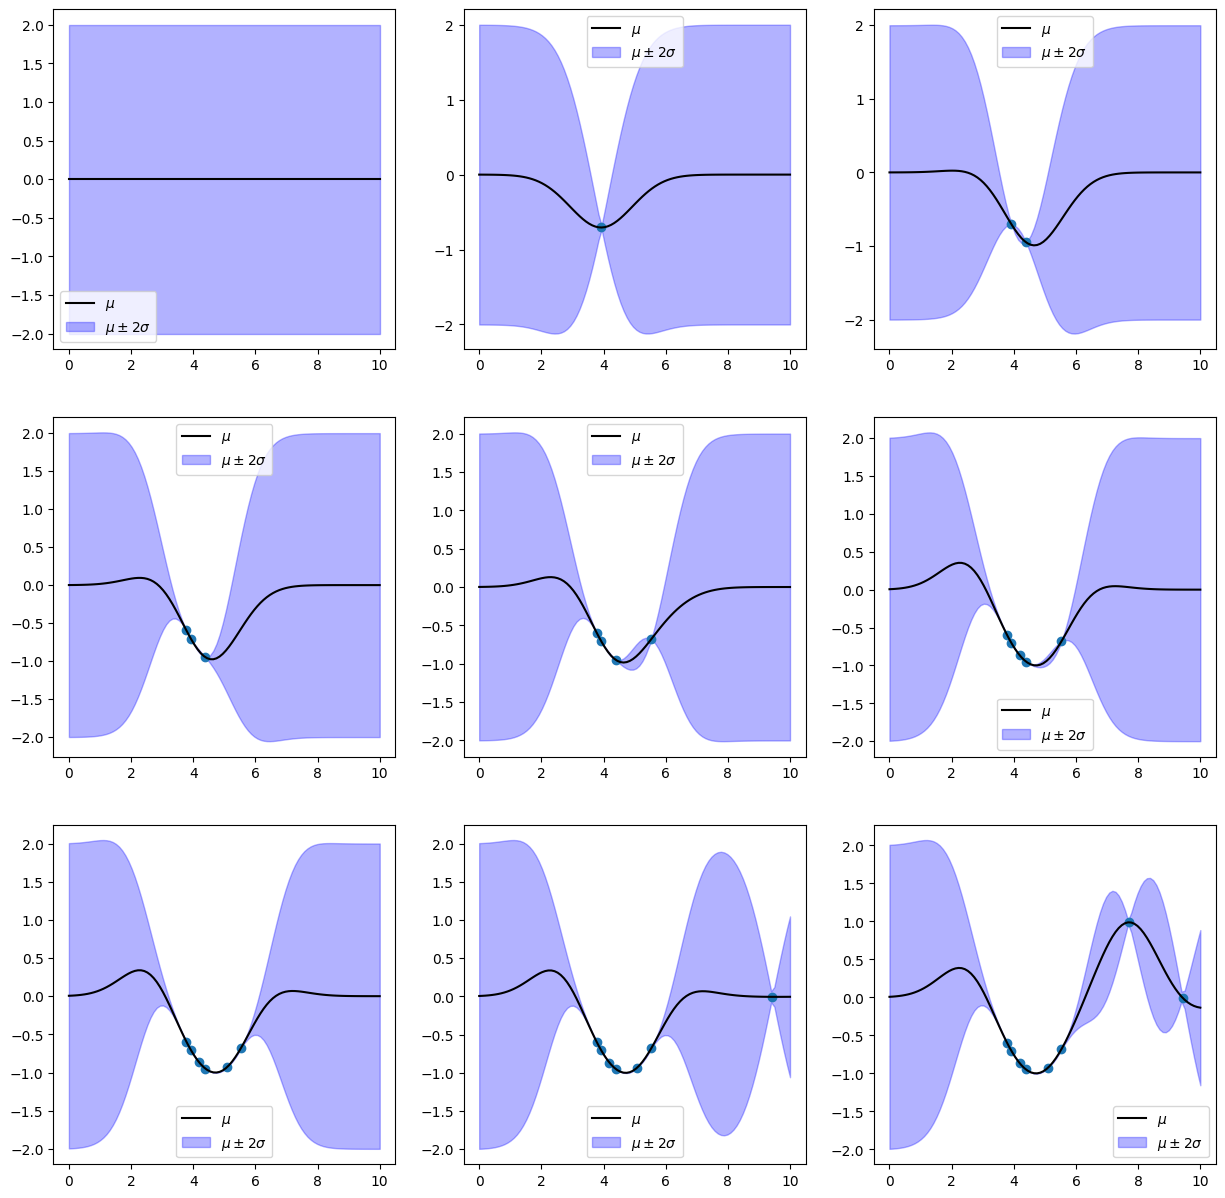

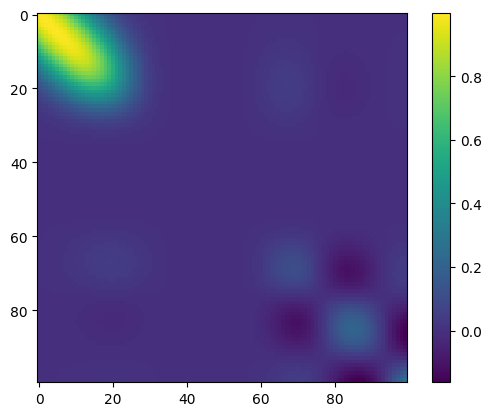

In [3]:
f = np.sin
gp = GaussianProcess(m=zero_mean, k=rbf)


fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

x_new = np.linspace(0, 10, 100)[:, None]
plot_gp(gp, x_new, axs.flat[0])
axs.flat[0].legend(loc=0)

for ax in axs.flat[1:]:
    x = np.random.random(1) * 10
    y = f(x)

    gp.observe(x[:, None], y)
    plot_gp(gp, x_new, ax)

    ax.legend(loc=0)
plt.show()


fig, ax = plt.subplots()
img = plot_gp_k(gp, x_new, ax)
plt.colorbar(img)
plt.show()

In [4]:
from functools import partial
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def minimize(f, x_sampler, x_bounds: list[tuple[float, float]] = None, n_init_samples: int = 100, n_starts: int = 10):
    x = x_sampler(n_init_samples)
    y = [f(xi) for xi in x]
    x = x[np.argsort(y)[:n_starts]]

    best_x = None
    best_y = float("inf")
    for x0 in x:
        res = scipy.optimize.minimize(f, x0=x0, bounds=x_bounds, method="L-BFGS-B")
        if res.fun < best_y:
            best_y = res.fun
            best_x = res.x
    return best_x

def bopt_1d(f, gp: GaussianProcess, acq_func, x_sampler, x_bounds, steps: int,
            n_init_samples: int = 3, interval: int = 600):
    x_new = np.linspace(x_bounds[0][0], x_bounds[0][1], 400)[:, None]
    f_new = np.asarray([f(xi) for xi in x_new], dtype=float)

    x_init = x_sampler(n_init_samples)
    y_init = np.asarray([f(xi) for xi in x_init], dtype=float)
    gp.observe(x_init, y_init)

    # Precompute snapshots so animation callbacks can be called in any order.
    snapshots = []
    best_y = float(np.max(y_init))
    for _ in range(steps):
        mu = gp.m(x_new)
        sigma2 = np.diag(gp.k(x_new, x_new))
        sigma = np.sqrt(np.maximum(sigma2, 0.0))
        acq = np.asarray([acq_func(x=xi, best_y=best_y) for xi in x_new], dtype=float)

        x = minimize(lambda x: -acq_func(x=x, best_y=best_y), x_sampler, x_bounds)
        y = float(f(x))
        snapshots.append({
            "mu": mu, "sigma": sigma, "acq": acq,
            "x_obs": gp.x.copy(), "y_obs": gp.y.copy(),
            "x_next": float(x[0]), "y_next": y,
        })

        gp.observe(x[:, None], np.array([y]))
        best_y = max(best_y, y)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax_acq = ax.twinx()
    x_plot = x_new[:, 0]

    gp_low = min(np.min(s["mu"] - 2*s["sigma"]) for s in snapshots)
    gp_high = max(np.max(s["mu"] + 2*s["sigma"]) for s in snapshots)
    y_low = min(float(np.min(f_new)), gp_low)
    y_high = max(float(np.max(f_new)), gp_high)
    y_pad = 0.05 * max(y_high - y_low, 1.0)

    def update(frame):
        state = snapshots[frame]
        ax.clear()
        ax_acq.clear()

        ax.plot(x_plot, f_new, "r--", alpha=0.35, label=r"$f$")
        ax.plot(x_plot, state["mu"], "k", label=r"$\mu$")
        ax.fill_between(
            x_plot, state["mu"] - 2*state["sigma"], state["mu"] + 2*state["sigma"],
            color="blue", alpha=0.25, label=r"$\mu \pm 2\sigma$",
        )
        ax.scatter(state["x_obs"][:, 0], state["y_obs"], color="C0", zorder=3, label="observed")
        ax.scatter(state["x_next"], state["y_next"], marker="*", s=180,
                   color="C1", zorder=4, label="selected")
        ax.axvline(state["x_next"], color="C1", linestyle=":", alpha=0.7)
        ax_acq.plot(x_plot, state["acq"], color="C3", alpha=0.8, label="acquisition")

        ax.set_xlim(x_bounds[0])
        ax.set_ylim(y_low - y_pad, y_high + y_pad)
        ax.set_xlabel("x")
        ax.set_title(f"Bayesian optimization step {frame + 1}/{steps}")

        handles, labels = ax.get_legend_handles_labels()
        acq_handles, acq_labels = ax_acq.get_legend_handles_labels()
        ax.legend(handles + acq_handles, labels + acq_labels, loc="upper left")

    animation = FuncAnimation(fig, update, frames=steps, interval=interval, repeat=False)
    result = HTML(animation.to_jshtml())
    plt.close(fig)
    return result


def p_improve(x: np.ndarray, best_y: float, gp: GaussianProcess):
    mu = gp.m(x)[0]
    sigma2 = gp.k(x, x)[0, 0]
    sigma = np.sqrt(np.maximum(sigma2, 0.0))
    return scipy.stats.norm.cdf((mu - best_y) / sigma)

def f(x: np.ndarray):
    return -0.25 * x[0]**4 + 0.4 * x[0]**3 + 0.7 * x[0]**2

x_bounds = [(-2.0, 3.0)]
x_sampler = lambda n: np.random.uniform(x_bounds[0][0], x_bounds[0][1], n)[:, None]

gp = GaussianProcess(m=zero_mean, k=partial(rbf, sigma2=10), sigma2_noise=0.0)
acq_func = partial(p_improve, gp=gp)

bopt_1d(f, gp, acq_func, x_sampler, x_bounds, steps=16)

In [5]:
def E_improve(x: float, best_y: float, gp: GaussianProcess):
    mu = gp.m(x)[0]
    sigma = np.sqrt(np.maximum(gp.k(x, x)[0, 0], 0))
    z = (mu - best_y) / sigma
    return (mu - best_y) * scipy.stats.norm.cdf(z) + sigma * scipy.stats.norm.pdf(z)

gp = GaussianProcess(m=zero_mean, k=partial(rbf, sigma2=10), sigma2_noise=0.0)
acq_func = partial(E_improve, gp=gp)
bopt_1d(f, gp, acq_func, x_sampler, x_bounds, steps=16)

In [6]:
def ucb(x: np.ndarray, best_y: float, c: float, gp: GaussianProcess):
    mu = gp.m(x)[0]
    sigma = np.sqrt(np.maximum(gp.k(x, x)[0, 0], 0))
    return mu + c*sigma

gp = GaussianProcess(m=zero_mean, k=partial(rbf, sigma2=10), sigma2_noise=0.0)
acq_func = partial(ucb, gp=gp, c=2.0)
bopt_1d(f, gp, acq_func, x_sampler, x_bounds, steps=16)